In [1]:
import tensorflow as tf
from tensorflow.keras import models,layers
import matplotlib.pyplot as plt

In [19]:
image_size=224
batch_size=8
channels=3

In [8]:
dataset=tf.keras. preprocessing.image_dataset_from_directory(
    r"C:\Users\Sadiya Sajid\Downloads\potato_disease\PlantVillage",
    shuffle=True,
    image_size=(image_size,image_size),
    batch_size=batch_size
)

Found 2152 files belonging to 3 classes.


In [10]:
class_names=dataset.class_names
class_names

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [11]:
len(dataset)

269

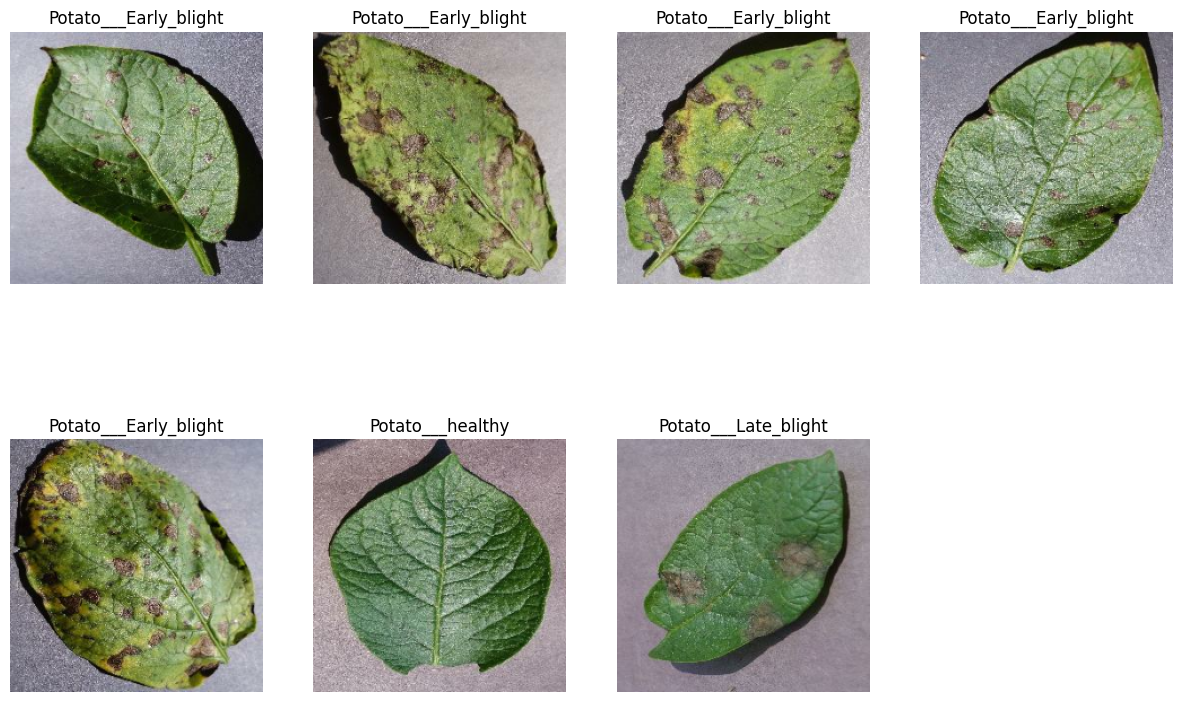

In [28]:
plt.figure(figsize=(15,15))
for image_batch,label_batch in dataset.take(1):
    for i in range(7):
        ax=plt.subplot(3,4,i+1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[label_batch[i]])
        plt.axis("off")

In [32]:
def dataset_partition(ds,train_split=0.7,val_split=0.15,test_split=0.15,shuffle=True,shuffle_size=1000):
    ds_size=len(ds)

    if shuffle:
        ds=ds.shuffle(shuffle_size,seed=12)

    train_size=int(train_split*ds_size)
    val_size=int(val_split*ds_size)

    train_ds=ds.take(train_size)
    val_ds=ds.skip(train_size).take(val_size)
    test_ds=ds.skip(train_size).skip(val_size)
    
    return train_ds,val_ds,test_ds

In [33]:
train_ds,val_ds,test_ds=dataset_partition(dataset)

In [43]:
len(train_ds)

188

In [42]:
len(val_ds)

40

In [39]:
len(test_ds)

41

In [44]:
train_ds=train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds=val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds=test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [46]:
resize_and_rescaling=tf.keras.Sequential([
    layers.experimental.preprocessing.Resizing(image_size,image_size),
    layers.experimental.preprocessing.Rescaling(1.0/255)
])

In [47]:
data_augumentation=tf.keras.Sequential([
    layers.experimental.preprocessing.RandomFlip("horizontal_and_vertical"),
    layers.experimental.preprocessing.RandomRotation(0.2)
])

In [50]:
input_shape=(batch_size,image_size,image_size,channels)
n_classes=3

model=tf.keras.Sequential([
    resize_and_rescaling,
    data_augumentation,

    layers.Conv2D(32,kernel_size=(3,3),activation='relu',input_shape=input_shape),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,kernel_size=(3,3),activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,kernel_size=(3,3),activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,kernel_size=(3,3),activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dense(n_classes,activation="softmax")
])

model.build(input_shape=input_shape)

In [52]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (8, 224, 224, 3)          0         
                                                                 
 sequential_1 (Sequential)   (8, 224, 224, 3)          0         
                                                                 
 conv2d (Conv2D)             (8, 222, 222, 32)         896       
                                                                 
 max_pooling2d (MaxPooling2  (8, 111, 111, 32)         0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (8, 109, 109, 64)         18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (8, 54, 54, 64)           0         
 g2D)                                                 

In [54]:
model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"]
)

In [59]:
history=model.fit(
    train_ds,
    epochs=25,
    batch_size=batch_size,
    verbose=1,
    validation_data=val_ds
)

Epoch 1/25
188/188 [==============================] - 25s 133ms/step - loss: 0.1829 - accuracy: 0.9269 - val_loss: 0.1520 - val_accuracy: 0.9469
Epoch 2/25
188/188 [==============================] - 25s 132ms/step - loss: 0.1809 - accuracy: 0.9415 - val_loss: 0.2359 - val_accuracy: 0.9031
Epoch 3/25
188/188 [==============================] - 25s 133ms/step - loss: 0.1734 - accuracy: 0.9388 - val_loss: 0.4369 - val_accuracy: 0.8656
Epoch 4/25
188/188 [==============================] - 25s 134ms/step - loss: 0.1522 - accuracy: 0.9488 - val_loss: 0.2172 - val_accuracy: 0.9125
Epoch 5/25
188/188 [==============================] - 25s 132ms/step - loss: 0.1337 - accuracy: 0.9495 - val_loss: 0.1349 - val_accuracy: 0.9531
Epoch 6/25
188/188 [==============================] - 25s 133ms/step - loss: 0.1369 - accuracy: 0.9495 - val_loss: 0.2191 - val_accuracy: 0.9156
Epoch 7/25
188/188 [==============================] - 23s 122ms/step - loss: 0.1192 - accuracy: 0.9574 - val_loss: 0.1428 - val_ac

In [60]:
scores=model.evaluate(test_ds)

41/41 [==============================] - 5s 57ms/step - loss: 0.0455 - accuracy: 0.9909


In [61]:
history.params

{'verbose': 1, 'epochs': 25, 'steps': 188}

In [67]:
history.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

In [68]:
acc=history.history["accuracy"]
val_acc=history.history["val_accuracy"]

loss=history.history["loss"]
val_loss=history.history["val_loss"]

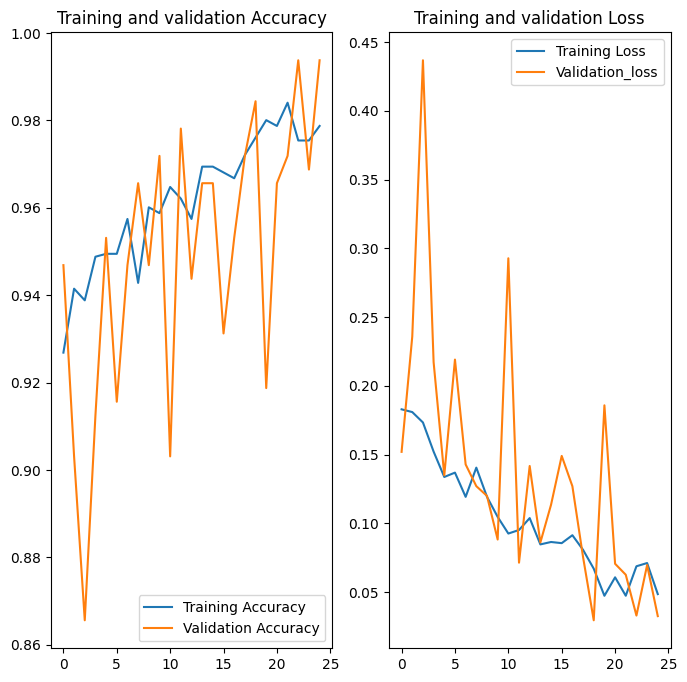

In [74]:
epochs=25
plt.figure(figsize=(8,8))
plt.subplot(1,2,1)
plt.plot(range(epochs),acc,label="Training Accuracy")
plt.plot(range(epochs),val_acc, label="Validation Accuracy")
plt.legend(loc="lower right")
plt.title("Training and validation Accuracy")

plt.subplot(1,2,2)
plt.plot(range(epochs),loss,label="Training Loss")
plt.plot(range(epochs),val_loss,label="Validation_loss")
plt.legend(loc="upper right")
plt.title("Training and validation Loss")

plt.show()

Actual Image:  Potato___Early_blight
1/1 [==============================] - 0s 103ms/step
Predicted Image Potato___Early_blight


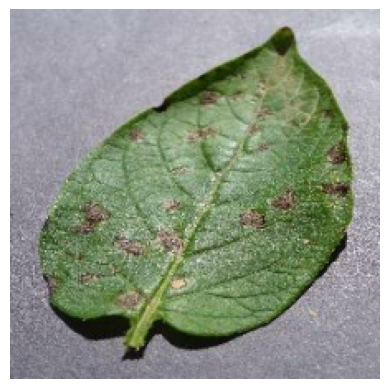

In [86]:
import numpy as np
for images_batch,labels_batch in test_ds.take(1):
    first_image=images_batch[0].numpy().astype("uint8")
    first_label=labels_batch[0].numpy()

    plt.imshow(first_image)
    print("Actual Image: ",class_names[first_label])
    predict=model.predict(images_batch)
    print("Predicted Image",class_names[np.argmax(predict[0])])
    plt.axis("off")
    

In [103]:
def predict(model,img):
    img_array=tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array=tf.expand_dims(img_array,0)

    predictions=model.predict(img_array)

    predict_class=class_names[np.argmax(predictions[0])]
    confidence=round(100*(np.max(predictions[0])),2)

    return predict_class,confidence

1/1 [==============================] - 0s 72ms/step


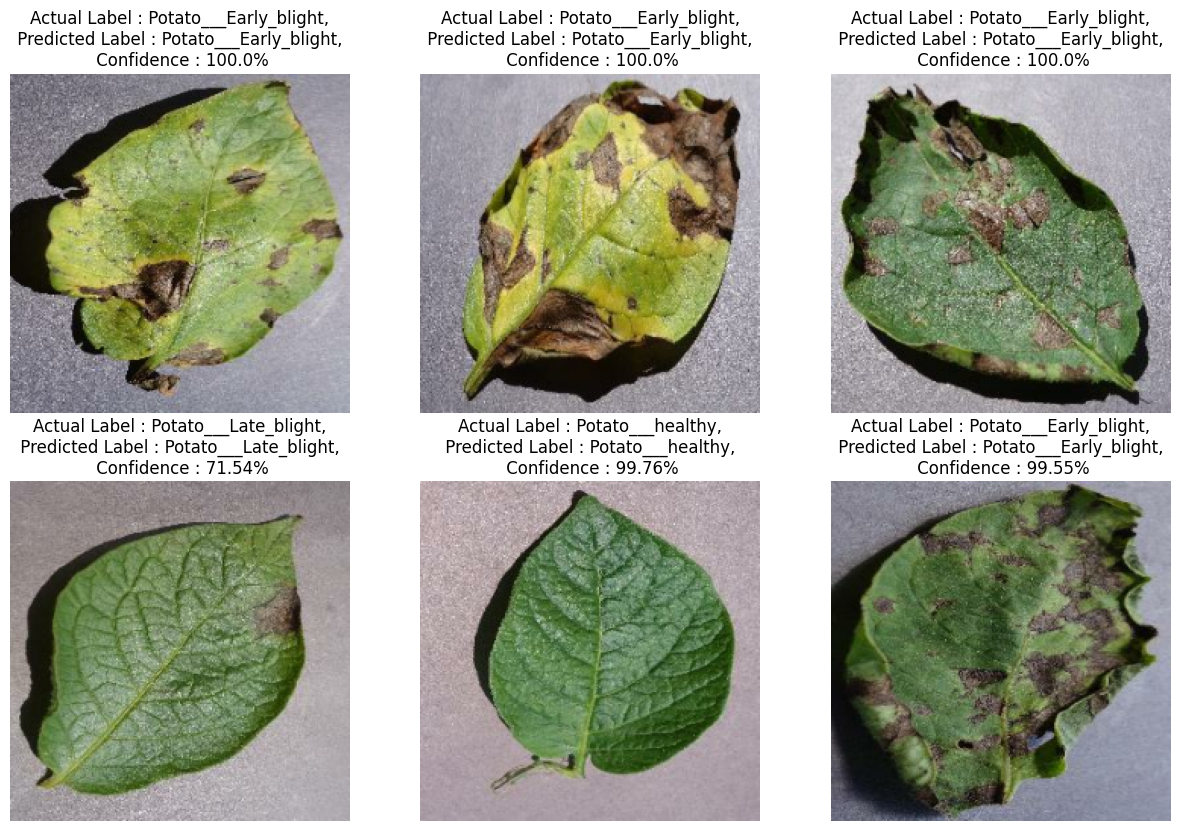

In [108]:
plt.figure(figsize=(15,15))
for images,labels in test_ds.take(1):
    for i in range(6):
        ax=plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))

        predict_class,confidence=predict(model,images[i].numpy())
        actual_class=class_names[labels[i]]

        plt.title(f"Actual Label : {actual_class},\n Predicted Label : {predict_class}, \n Confidence : {confidence}%")
        plt.axis("off")
    

In [114]:
model_version=1
model.save(f"../model/{model_version}")

INFO:tensorflow:Assets written to: ../model/1\assets


INFO:tensorflow:Assets written to: ../model/1\assets
